# Basic code for a quantum integral in Python with PennyLane. 

### Block 1: Environment and Parameter Configuration

Here we define the quantum "working space". It is important to explain that the greater the number of qubits (n), the greater the resolution of the discretization of the interval [s, t].

In [9]:
# Librerias
import pennylane as qml 
import numpy as np

In [10]:
# Configuración del dispositivo
n = 8  # Número de qubits
N = 2**n  # Resolución: puntos discretos en el intervalo
dev = qml.device("default.qubit", wires=n)

# Parámetros de la función a integrar
p = 4
s, t = -1, 1

### Block 2: State Preparation (Superposition)

The goal is to put all qubits into the state |+>. This allows the system to represent all numbers between 0 and [(2^n) - 1] with equal probability at the start.

* QFT Application

This is where the "magic" happens. The QFT shifts the information into the frequency domain. The structure we use (Hadamard + CNOT + RZ) is the manual implementation of this operator. (mentioned en up cell)

* Inverting the QFT (IQFT) and Measurement

To obtain results in the time/space domain, we must invert the QFT. By measuring, we collapse the state into a probability distribution that reflects the values ​​of our function.

In [ ]:
@qml.qnode(dev)  
def circuit():
    # Inicialización: Superposición uniforme sobre la base computacional
    for i in range(n):
        qml.Hadamard(wires=i)
    
    # QFT Application ----------------------------------------------------------
    # Aplicar Quantum Fourier Transform (QFT)
    for i in range(n):
        qml.Hadamard(wires=i) 
        for j in range(i+1, n):
           qml.CNOT(wires=[i, j]) 
           qml.RZ(2 * np.pi / (2 ** (j - i + 1)), wires=j) # Ajuste de fase
    
    # Inverting the QFT (IQFT) and Measurement ---------------------------------
    # Invertir la QFT (IQFT)
    for i in range(n-1, -1, -1):
        for j in range(i+1, n):
             qml.CNOT(wires=[i, j])
             qml.Hadamard(wires=i)
    
    return qml.probs(wires=range(n))
    

### Block 3: Post-processing (Integral Calculation)

Finally, we take the probabilities obtained from the quantum simulation and perform the weighted sum. This translates the "quantum output" into a classical mathematical value.

In [13]:
# Ejecución del circuito
# Nota: La función circuit() definida con @qml.qnode(dev) 
# devuelve directamente las probabilidades (qml.probs)
quasi_probs = circuit() 

# Ahora quasi_probs contiene un array de tamaño 2^n con 
# la probabilidad de cada estado.
print("Distribución de probabilidad obtenida:", quasi_probs)
# Mapeo de estados cuánticos a valores en [s, t]
x_values = np.linspace(s, t, N)

# Cálculo de la integral: Sumatoria (f(x) * P(x)) * dx
dx = (t - s) / N
integral_value = sum(x_values[state]**p * prob for state, prob in enumerate(quasi_probs)) * dx

Distribución de probabilidad obtenida: [3.21603373e-03 5.50386993e-03 1.20944172e-03 5.04754587e-04
 3.13796364e-03 5.70988352e-04 9.20651326e-04 3.70817519e-03
 7.30923610e-03 9.45998488e-03 2.70941257e-03 2.50103408e-03
 9.41671530e-03 1.79493954e-03 3.23114976e-03 9.09489328e-03
 8.44096152e-03 1.01616408e-02 2.76506905e-03 2.49792927e-03
 2.68298689e-03 1.16840808e-04 6.44464698e-03 1.14169325e-02
 2.44437942e-03 7.46720201e-03 1.72039124e-04 5.15587332e-04
 3.92676825e-04 6.09918740e-04 6.33802373e-03 5.08064008e-03
 5.54711342e-03 2.61406871e-03 2.81085363e-04 2.39088509e-03
 1.70055936e-03 1.79141711e-03 3.89426146e-03 1.52727379e-03
 1.17355980e-02 3.84594116e-03 8.31512370e-04 2.39165038e-03
 1.67907344e-03 4.03529598e-03 8.79709127e-03 7.02818879e-03
 9.55544539e-03 7.99700710e-04 4.03510819e-03 8.24747643e-03
 5.27868161e-03 2.18358195e-03 5.97436575e-03 6.74283619e-03
 1.03609071e-03 2.02297476e-06 8.87667074e-04 3.91764551e-03
 2.01802666e-03 3.88129180e-03 2.71732132e-04 

We printed our quantum circuit

In [14]:
# Esto imprimirá la representación visual en texto dentro de tu notebook
print(qml.draw(circuit)())

0: ──H──H─╭●───────────╭●───────────╭●───────────╭●───────────╭●───────────╭●───────────╭●──────────
1: ──H────╰X──RZ(1.57)─│────────────│────────────│────────────│────────────│────────────│───H───────
2: ──H─────────────────╰X──RZ(0.79)─│────────────│────────────│────────────│────────────│───────────
3: ──H──────────────────────────────╰X──RZ(0.39)─│────────────│────────────│────────────│───────────
4: ──H───────────────────────────────────────────╰X──RZ(0.20)─│────────────│────────────│───────────
5: ──H────────────────────────────────────────────────────────╰X──RZ(0.10)─│────────────│───────────
6: ──H─────────────────────────────────────────────────────────────────────╰X──RZ(0.05)─│───────────
7: ──H──────────────────────────────────────────────────────────────────────────────────╰X──RZ(0.02)

───────────────────────────────────────────────────────────────────────────────────────────────
──╭●───────────╭●───────────╭●───────────╭●───────────╭●───────────╭●──────────────────────────

Se espera un circuito cómo el siguiente (que es una imagen hecha con 15 qubits).
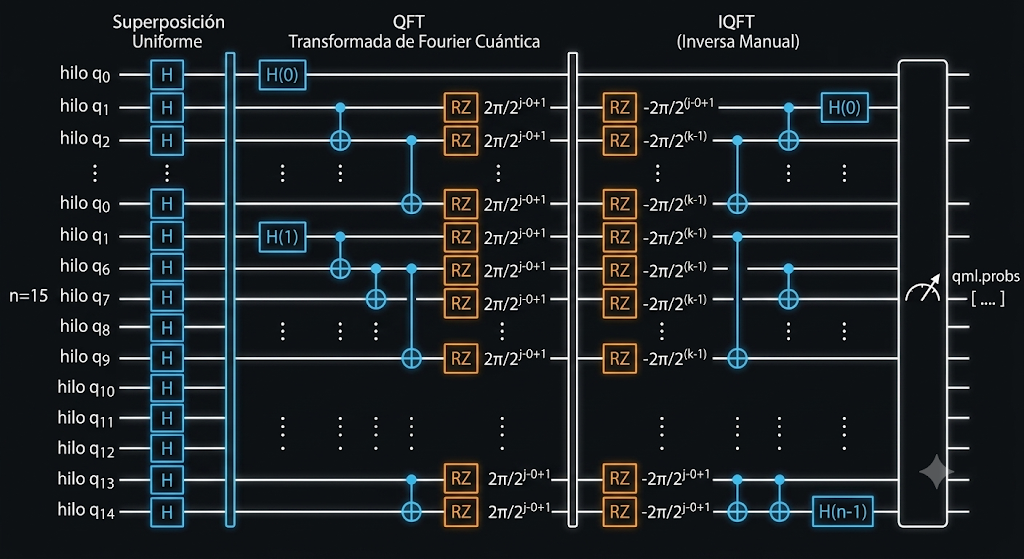